# In-Depth: Support Vector Machines

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# use Seaborn plotting defaults
import seaborn as sns; sns.set()

## Motivating Support Vector Machines
Consider a simple classification task, a dataset labeled with two classes that are well-separated.

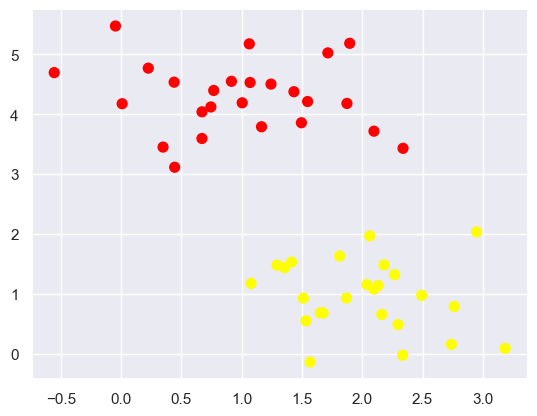

In [2]:
from sklearn.datasets import make_blobs
X, y = make_blobs(n_samples=50, centers=2, random_state=0, cluster_std=0.6)
plt.scatter(X[:,0], X[:, 1], c=y, s=50, cmap='autumn');

A linear discriminative classifier would determine a line that divides the data into two regions.

But in this case there are plenty of straight lines that perfectly divide the data.

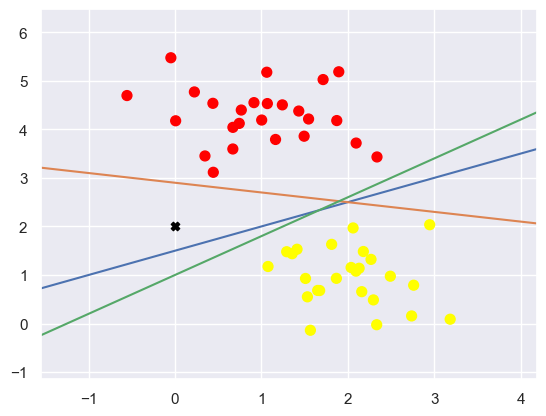

In [3]:
from sklearn.datasets import make_blobs
X, y = make_blobs(n_samples=50, centers=2, random_state=0, cluster_std=0.6)

xfit = np.linspace(X[:,0].min()-2, X[:,0].max()+2)
yfit = 0.5*xfit + 1.5

plt.scatter(X[:,0], X[:, 1], c=y, s=50, cmap='autumn')
plt.plot(xfit,0.5*xfit+1.5)
plt.plot(xfit,-0.2*xfit+2.9)
plt.plot(xfit,0.8*xfit+1)
plt.scatter(0,2, marker='X', c='black')

plt.xlim(X[:,0].min()-1, X[:,0].max()+1)
plt.ylim(X[:,1].min()-1,X[:,1].max()+1);

Solely using straight lines for classifications is not enough, since there are lots of those that may perfectly separate the two classes.

This is a problem because our prediction depends on which straight line we use.

Consider the black point above. If we use the blue straight line, the predicted label would be 'red'. On the other hand, if we use the red line, we would predict 'yellow'. Which straight line is correct?

## Support Vector Machines: Maximizing the Margin

Support vector machines offer a wayforward for this. Instead of drawing zero-width lines for classifying data, we add margins of width equal to the distance from the line to the nearest sample point.

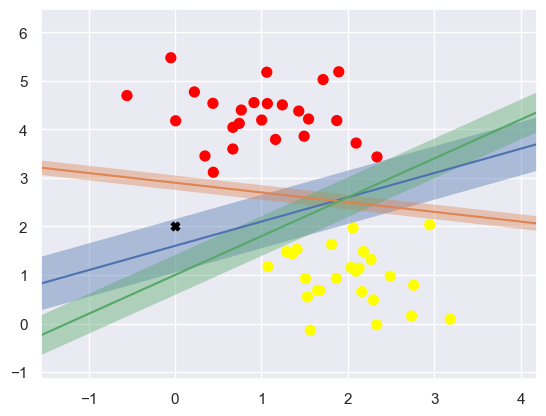

In [4]:
from sklearn.datasets import make_blobs
X, y = make_blobs(n_samples=50, centers=2, random_state=0, cluster_std=0.6)

xfit = np.linspace(X[:,0].min()-2, X[:,0].max()+2)

plt.scatter(X[:,0], X[:, 1], c=y, s=50, cmap='autumn')

for m,b,d in [(0.5,1.6,0.55),(-0.2,2.9,0.15),(0.8,1,0.41)]:#,,]:
    yfit = m*xfit+b
    plt.plot(xfit,yfit)
    plt.fill_between(xfit,yfit-d,yfit+d,edgecolor='none',alpha=0.4)
    
plt.scatter(0,2, marker='X', c='black')

plt.xlim(X[:,0].min()-1, X[:,0].max()+1)
plt.ylim(X[:,1].min()-1,X[:,1].max()+1);

In support vector machines, the line that maximizes the margin is chosen as the optimal model.

Support vector machines belong to a type of model called *maximum margin estimator*.

### Fitting a support vector machine

In [5]:
from sklearn.svm import SVC
model = SVC(kernel='linear', C=1E10)
model.fit(X,y)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",10000000000.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [6]:
def plot_svc_decision_function(model, X, y, ax=None, plot_support=True):
    if ax is None:
        ax = plt.gca()
        
    ax.scatter(X[:,0],X[:,1],c=y,cmap='autumn')
    
    x1,x2 = np.meshgrid(
        np.linspace(ax.get_xlim()[0],ax.get_xlim()[1]),
        np.linspace(ax.get_ylim()[0],ax.get_ylim()[1])
    )
    X_test = np.column_stack([x1.ravel(),x2.ravel()])
    Z = model.decision_function(X_test).reshape(x1.shape)
    
    # For the decision_function, value of 0 (level=0) corresponds to the line that maximizes the margins
    # level=-1 and level=1 correspond to the margins
    if plot_support == True:
        ax.contour(x1, x2, Z, colors='k', levels=[-1,0,1], linestyles=['--', '-', '--'])
        ax.scatter(model.support_vectors_[:,0],
          model.support_vectors_[:,1],
          s=200,
          facecolors='none',
          edgecolor='black');
    else:
        ax.contour(x1, x2, Z, colors='k', levels=[0], linestyles=['-'])


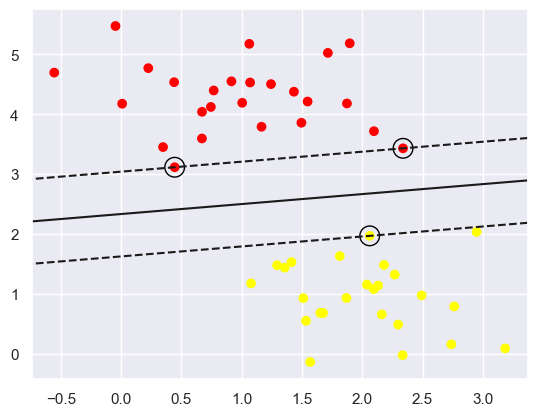

In [7]:
plot_svc_decision_function(model, X, y)

The solid line above is the dividing line that maximizes the margins (margins are shown as broken lines).

The encircled points (those touching the margins) determine that dividing line and are known as the **support vectors**.

A key to the success of this classifier is that only the positions of the support vectors matter. So, no matter how large the sample size is, as long as the support vectors don't change position, the model would not change.

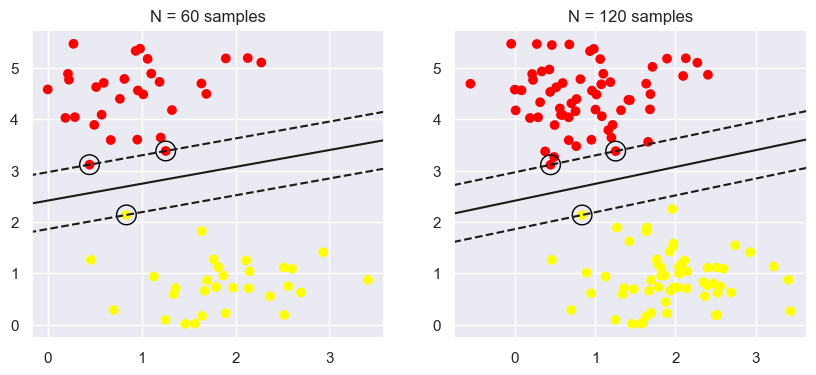

In [8]:
X,y = make_blobs(n_samples = 200, centers=2, random_state=0, cluster_std=0.60)

fig, axs = plt.subplots(1,2, figsize=(10,4))
for ax, N in zip(axs,[60,120]):
    X_samp = X[:N]
    y_samp = y[:N]
    model.fit(X_samp, y_samp)
    plot_svc_decision_function(model, X_samp, y_samp, ax)
    ax.set_title(f'N = {N} samples')

### Beyond linear boundaries: Kernel SVM

In the above example, we defined a support vector machine model and set the hyperparameter `kernel` as `linear`. But, the divider of the data need not be a line.

Similar to linear regression, in which we can use basis functions to fit nonlinear relationships with a linear model, we can use other nonlinear functions as *kernels* for the support vector machine model.

Consider the data below.

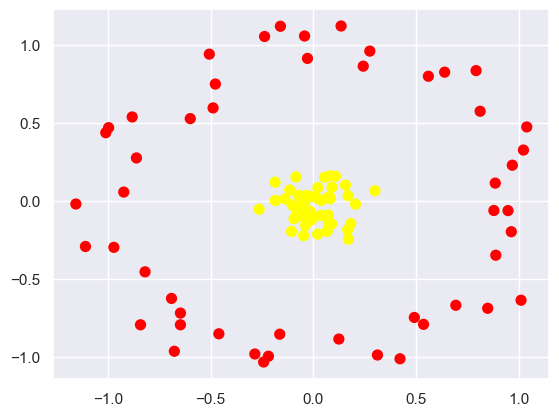

In [9]:
from sklearn.datasets import make_circles
X, y = make_circles(100, factor=.1, noise=.1)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn');

It is apparent that the appopriate curve that divides the data is a circle. If we try to fit the SVC model before...

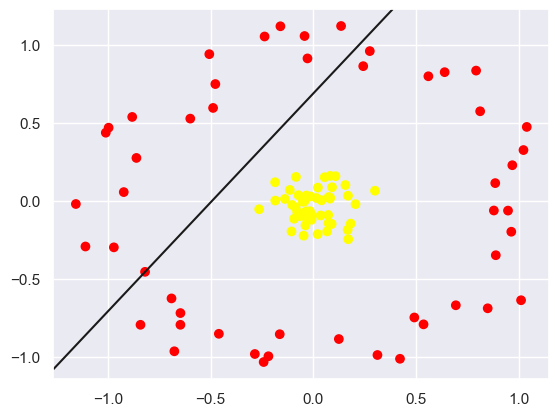

In [10]:
model = SVC(kernel='linear')
model.fit(X,y)
plot_svc_decision_function(model, X, y, plot_support=False);

it is clear that the model is ineffective.

Taking the idea from linear regression, we can project the data onto a higher dimension and then divide data with a hyperplane.

A simple projection would be using a *radial basis function* centered at the origin (where the middle clump is).
$$r(x_1,x_2) = e^{-(x_1^2+x_2^2)}$$

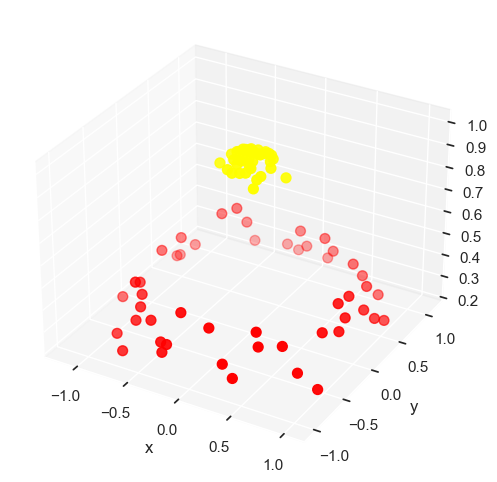

In [11]:
r = np.exp(-(X ** 2).sum(1))
from mpl_toolkits import mplot3d
def plot_3D(X=X, y=y):
    ax = plt.subplot(projection='3d')
    ax.scatter3D(X[:, 0], X[:, 1], r, c=y, s=50, cmap='autumn')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('r')
    ax.figure.set_size_inches(6,6)
    ax.set_facecolor('1')
plot_3D()

As we can see, we can sort of place a plane at about $r=0.5$ to divide the data.

The choice of the function $r$ was not arbitrary. Of course, we have to find the right center (coincidentally at the origin) and find the right width.

In general, the radial basis function kernel can be expressed as
$$r(x) = \exp(-\gamma ||x-c||^2)$$

where $x$ is each sample, $c$ is the center, and $\gamma$ dictates the width.

It is a problem to find the best basis function. One strategy is to consider all radial basis function kernels centered at all data points, i.e., to consider
$$r(x,x') = \exp(-\gamma ||x-x'||^2)$$

for each sample $x'$. For $N$ samples, this results in projecting our data onto $N$ dimensions.

A potential problem with this strategy is that it might become computationally intensive, especially for higher values of $N$. This is solved by the so-called **kernel trick**! With this, we can find a hyperplane on the kernel-transformed data without generating the full $N$-dimensional kernel projection.

The kernel trick is already built in Scikit-Learn; so there's no need to worry. (...I will learn all about the theory later on)

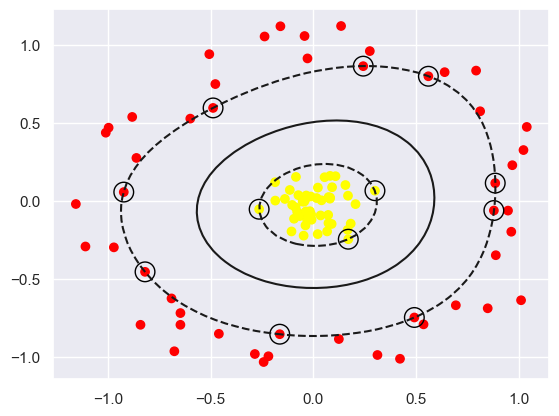

In [12]:
model = SVC(kernel='rbf', C=1E6)
model.fit(X,y)
plot_svc_decision_function(model, X, y)

Awesome!

### Tuning the SVM: Softening margins

Consider the following data

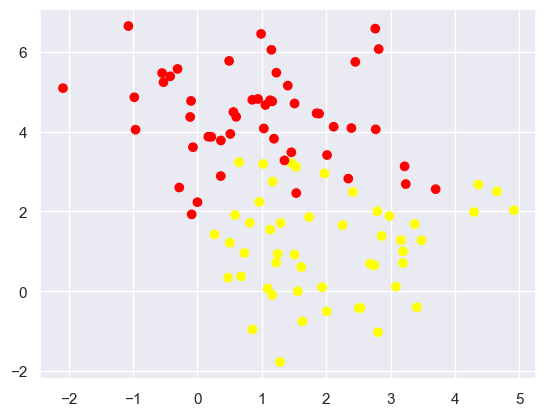

In [13]:
X,y = make_blobs(n_samples=100, centers=2,
                random_state=0, cluster_std=1.2)
plt.scatter(X[:,0], X[:,1], c=y, cmap='autumn');

It is clear that it would be difficult to find a separator of classes (linear or not).

In our previous SVM models, we specified the hyperparameter `C`; this one actually controls the 'softness' of the margins. for large values of `C`, the margin is stricter and cannot let points past it. For smaller values of `C`, the margin is softer, and allows some points if it results in a better fit.

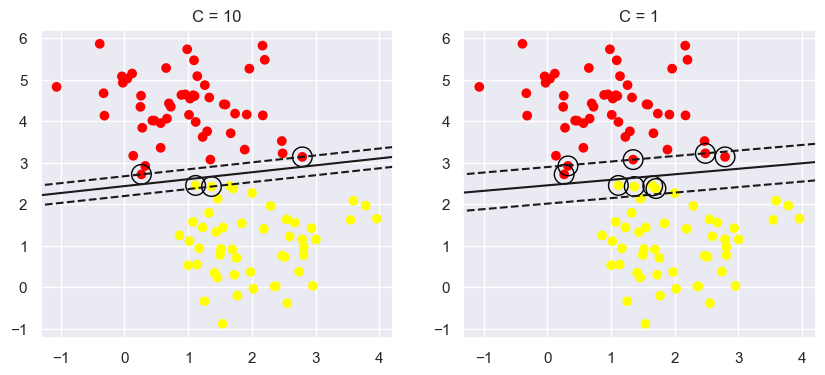

In [14]:
# C parameter demo
X,y = make_blobs(n_samples=100, centers=2, random_state=0, cluster_std=0.8)

fig, axs = plt.subplots(1,2, figsize=(10,4))
for ax,c in zip(axs,[10,1]):
    model = SVC(kernel='linear', C=c).fit(X,y)
    plot_svc_decision_function(model, X, y, ax=ax)
    ax.set_title(f'C = {c}')

With `C=10`, the margins are stricter, and in turn results in a narrower margin, especially for data that are not easily separable.

With `C=1`, the margins are softer, allows more points near the boundary, and results to wider margins.

In practice, this is tuned via cross-validation.

## Example: Face Recognition

Objective: use support vector machines to recognize faces

In [19]:
from sklearn.datasets import fetch_lfw_people
path = '~/IBM-Data-Science-Specialization/Course-9_Machine-Learning/data/Labeled_Faces_in_the_Wild'
faces = fetch_lfw_people(data_home=path,min_faces_per_person=60)
print(faces.target_names)
print(faces.images.shape)

['Ariel Sharon' 'Colin Powell' 'Donald Rumsfeld' 'George W Bush'
 'Gerhard Schroeder' 'Hugo Chavez' 'Junichiro Koizumi' 'Tony Blair']
(1348, 62, 47)


By setting `min_faces_per_person` to 60, we retrieve a sample of the dataset containing images of the people who have a minimum of 60 images in the dataset.

And there are only 8 such people.

In [67]:
faces.target_names.shape

(8,)

Similar to the handwritten digits dataset, the `.images` attribute is an array of 62 pixels x 47 pixels corresponding to an image.

In [24]:
faces.images[0].shape

(62, 47)

Our sample of the data, `faces`, contains 1348 different images of the 8 people.

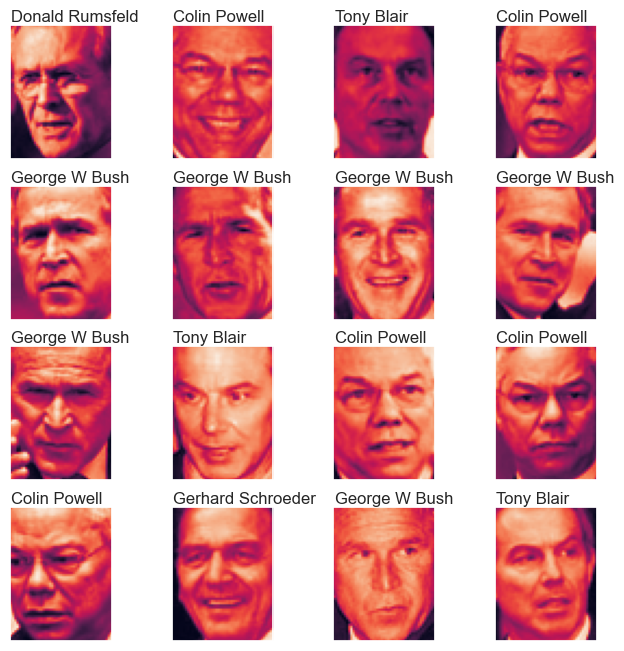

In [58]:
from PIL import Image

fig,axes = plt.subplots(
    4, 4, figsize=(8,8),
    subplot_kw = {'xticks': [], 'yticks': []}
)

ids = np.random.randint(0,faces.images.shape[0],16)
for i,ax in zip(ids, axes.flat):
    name = faces.target_names[faces.target[i]]
    ax.imshow(faces.images[i])
    ax.text(0.05, -2, str(name))

Like the handwritten digits, a clean features matrix and target matrix is already provided.

The idea of processing the features matrix is the same as before. Each sample is a 62 x 47 array of pixels. We flatten each to a 1D array and consider each pixel as a feature; giving us 62 x 47 = 2914 features.

In [60]:
X = faces.data
y = faces.target
X.shape, y.shape

((1348, 2914), (1348,))

### Visualization by Dimensionality reduction

Is this the standard way of doing things?

I don't know of any other way we can do exploration before diving into classification.

So, let's just try...

In [73]:
from sklearn.manifold import Isomap

transformer = Isomap(n_components=2)

data_projected = transformer.fit_transform(X)
data_projected.shape

(1348, 2)

''

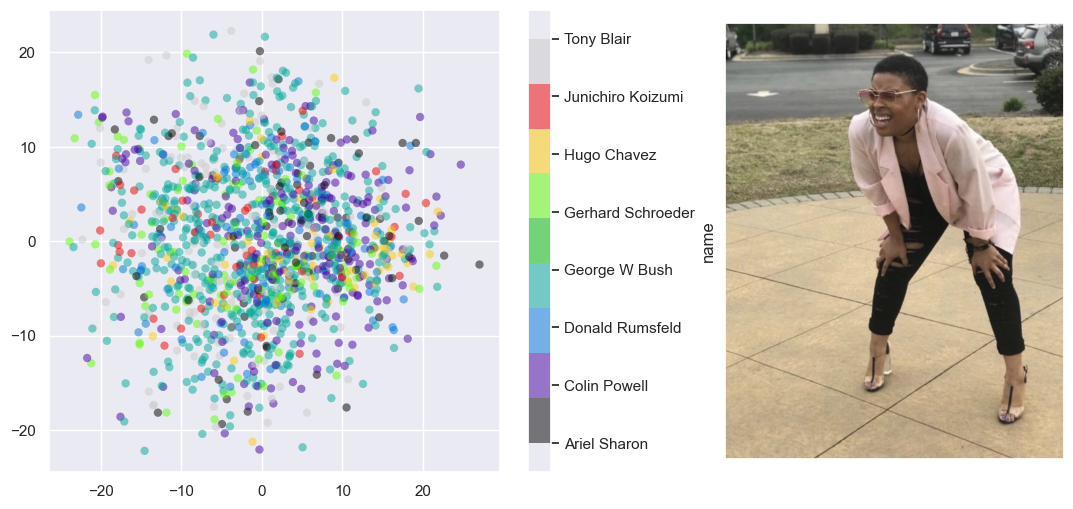

In [168]:
import os

fig = plt.figure(figsize=(16,6))
grid = plt.GridSpec(6, 6, hspace=0.2, wspace=1)
main_ax = fig.add_subplot(grid[:, 1:4])
meme_ax = fig.add_subplot(grid[:,4:], yticks=[], xticks=[])

cax = main_ax.scatter(
    data_projected[:,0],
    data_projected[:,1],
    c = y,
    edgecolor = 'none', alpha = 0.5,
    cmap = plt.get_cmap('nipy_spectral', 9)
)

cbar = plt.colorbar(cax, label='name', ticks=range(8))
cbar.ax.set_ylim(-0.5,7.5)
cbar.ax.set_yticklabels(faces.target_names)

meme_dir = os.path.abspath(os.path.join(os.getcwd(),os.pardir,'assets','what-am-i-looking-at.jpg'))
meme = np.asarray(Image.open(meme_dir))
meme_ax.imshow(meme)


;

Unlike what was previously done on the handwritten digits dataset, there's too much overlap among features that it is difficult to identify the classes from the graph. Nevertheless, one insight I can draw from this is that the dataset has lots of pictures of George W Bush.

### Classification

In [182]:
from sklearn.model_selection import GridSearchCV, train_test_split

param_grid = [{
    'kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
    'C': [0.1, 1, 100, 1E3, 1E4, 1E5, 1E6],
}]
model = SVC()
Grid = GridSearchCV(model, param_grid)

Grid.fit(X,y)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'C': [0.1, 1, ...], 'kernel': ['linear', 'poly', ...]}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candida

The optimal hyperparameters fall at the edge, with `kernel = linear` and `C=0.1`. I'll try to expand the grid to check if this is the true optimum.

This time I'll include the hyperparameter `gamma`, but also consider a smaller range for `C` and consider only linear, polynomial, and radial basis function kernels.

I'll also redefine the hyperparameter grid so that the kernels are only paired with the necessary hyperparameters (e.g. `degree` with `poly` only)

In the book solution, they preprocessed the data with a randomized PCA for some reason -- they just said "often it is more effective to use some sort of preprocessor to extract more meaningful features". So, we'll try that out too.

In [212]:
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

model_new = Pipeline([
    ('transform', PCA(svd_solver='randomized')),
    ('classifier', SVC())
])

param_grid_new = [
    {
        'transform__n_components': [10, 50, 100, 150, 200],
        'classifier__kernel': ['linear'],
        'classifier__C': [1, 5, 10, 50, 100],
    },
    {
        'transform__n_components': [10, 50, 100, 150, 200],
        'classifier__kernel': ['rbf', 'poly'],
        'classifier__C': [1, 5, 10, 50, 100],
        'classifier__gamma': [0.0001, 0.0005, 0.001, 0.005]
    },
    {
        'transform__n_components': [10, 50, 100, 150, 200],
        'classifier__kernel': ['rbf', 'poly'],
        'classifier__C': [1, 5, 10, 50, 100],
        'classifier__gamma': [0.0001, 0.0005, 0.001, 0.005],
        'classifier__degree': [2, 3, 4, 5, 7]
    }
]

grid_new = GridSearchCV(model_new, param_grid_new)

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

%time grid_new.fit(X_train,y_train)
print('best hyperparameters:', grid_new.best_params_)
print('best score:          ', grid_new.best_score_)

CPU times: user 11min 7s, sys: 47.2 s, total: 11min 54s
Wall time: 11min 35s
best hyperparameters: {'classifier__C': 50, 'classifier__degree': 3, 'classifier__gamma': 0.0005, 'classifier__kernel': 'rbf', 'transform__n_components': 200}
best score:           0.8249573233185388


In [216]:
BestSVC = grid_new.best_estimator_
ypred = BestSVC.predict(X_test)

To get a better read of the performance, I'll generate a classification report.

In [217]:
from sklearn.metrics import classification_report
print(classification_report(y_test, ypred, target_names=faces.target_names))

                   precision    recall  f1-score   support

     Ariel Sharon       0.71      0.67      0.69        15
     Colin Powell       0.81      0.85      0.83        68
  Donald Rumsfeld       0.72      0.74      0.73        31
    George W Bush       0.90      0.84      0.87       126
Gerhard Schroeder       0.61      0.74      0.67        23
      Hugo Chavez       0.92      0.55      0.69        20
Junichiro Koizumi       0.86      1.00      0.92        12
       Tony Blair       0.77      0.86      0.81        42

         accuracy                           0.81       337
        macro avg       0.79      0.78      0.78       337
     weighted avg       0.82      0.81      0.81       337



I'll also generate a confusion matrix.

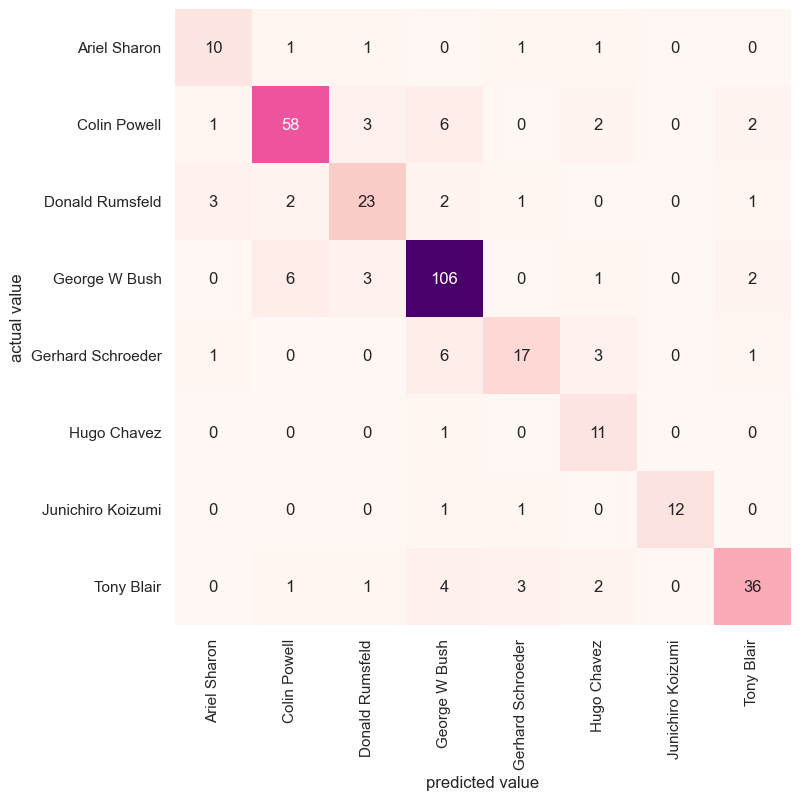

In [218]:
from sklearn.metrics import confusion_matrix

mat = confusion_matrix(y_test, ypred)
plt.figure(figsize=(12,8))
sns.heatmap(mat.T, square=True, annot=True, cbar=False, cmap='RdPu', fmt='g',
           xticklabels = faces.target_names,
           yticklabels = faces.target_names,
           )
plt.xlabel('predicted value')
plt.ylabel('actual value')
plt.show()

Another way to visualize how well the model performed is to look at a few images and check which were predicted correctly, and which were not.

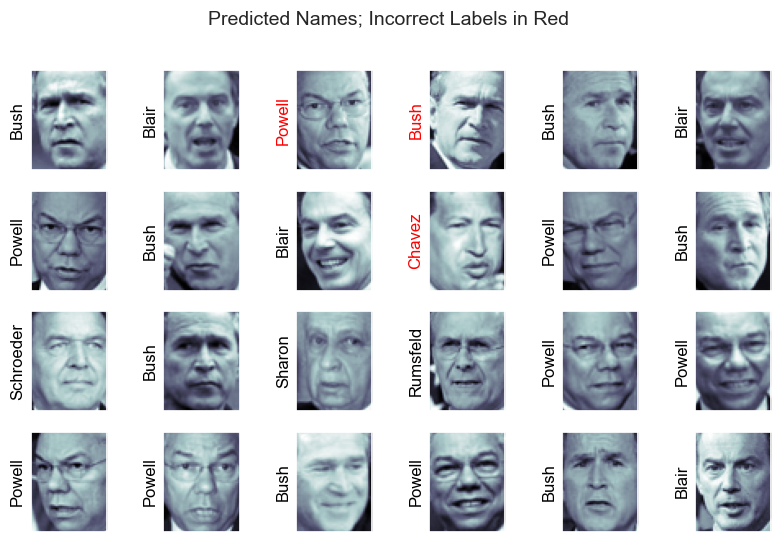

In [219]:
fig,axs = plt.subplots(4, 6,
                      figsize=(10,6),
                      subplot_kw = {'xticks': [], 'yticks': []})
ids = np.random.choice(y_test.shape[0], 24, replace=False)
for i,ax in zip(ids,axs.flat):
    last_name = faces.target_names[y_test[i]].split()[-1]
    ax.imshow(X_test[i].reshape(62, 47), cmap='bone')
    ax.set_ylabel(last_name,
                 color='black' if ypred[i]==y_test[i] else 'red')
fig.suptitle('Predicted Names; Incorrect Labels in Red', size = 14);

The model has some room for improvements. Perhaps I should just consider a fixed `kernel` and a fixed `n_decompostion` for the transformation. Hopefully I get to know more about this later.